*@author: petra.boskovic*

# 1. Install and Import Libraries

In [1]:
#!pip install -q kagglehub xgboost

In [2]:
import os
import gc
import glob
import time
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats as sp_stats
from scipy.signal import butter, sosfiltfilt, resample_poly, welch, find_peaks

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV, LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
)

from xgboost import XGBClassifier

import kagglehub
warnings.filterwarnings("ignore")

In [3]:
np.random.seed(42)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 2. Configuration

In [5]:
# 60 s windows are the de-facto standard for WESAD: they are long enough to
# estimate heart-rate variability and respiration rate reliably (a 60 s window
# contains ~60-100 heart beats and ~15 breaths), and short enough that the
# affective state is stationary inside the window.
WINDOW_SEC = 60.0
# 15 s shift => 75 % overlap. This multiplies the number of training samples by
# 4 compared to non-overlapping windows, which matters a lot because the raw
# dataset only holds ~36 minutes of usable labelled signal per subject.
# Overlapping windows are highly correlated, which is exactly why the
# evaluation protocol below is Leave-One-Subject-Out: no subject ever appears
# in both train and test, so the overlap cannot leak.
STEP_SEC = 15.0
# A window is only accepted if at least this fraction of its 700 Hz label
# samples carry one single class. This removes transition windows that straddle
# two conditions.
LABEL_PURITY = 0.98

In [6]:
KEEP_LABELS = {1: "baseline", 2: "stress", 3: "amusement"}
CLASS_ORDER = ["baseline", "stress", "amusement"]

In [7]:
# Chest signals are decimated to the lowest rate that still preserves the
# physiology, which cuts feature-extraction time and memory by ~10x:
#   ECG  700 Hz : kept, R-peak timing accuracy (~1.4 ms) drives all HRV features
#   EMG  700 Hz : kept, muscle activity energy lives at 50-350 Hz
#   Resp  70 Hz : breathing is < 1 Hz, 70 Hz is already 70x oversampled
#   ACC   70 Hz : human motion is < 20 Hz
#   EDA    7 Hz : skin-conductance responses are < 1 Hz (E4 itself samples 4 Hz)
#   Temp   7 Hz : skin temperature drifts over tens of seconds
CHEST_TARGET_FS = {
    "ECG": 700.0,
    "EMG": 700.0,
    "Resp": 70.0,
    "ACC": 70.0,
    "EDA": 7.0,
    "Temp": 7.0,
}

In [8]:
# Wrist signals are already low-rate, so they are used at their native rate.
WRIST_FS = {"ACC": 32.0, "BVP": 64.0, "EDA": 4.0, "TEMP": 4.0}

In [9]:
USE_CHEST = True
USE_WRIST = True

In [10]:
# Hyperparameter search uses grouped K-fold (groups = subjects) on the full
# feature table, the final score comes from Leave-One-Subject-Out.
TUNING_FOLDS = 5
N_JOBS = -1
RANDOM_STATE = 42

In [11]:
RUN_NESTED_CV = False

In [12]:
print(f"Window: {WINDOW_SEC:.0f} s, step: {STEP_SEC:.0f} s, classes: {list(KEEP_LABELS.values())}")

Window: 60 s, step: 15 s, classes: ['baseline', 'stress', 'amusement']


# 3. Download Dataset with kagglehub

In [13]:
DATA_ROOT = kagglehub.dataset_download(
    "orvile/wesad-wearable-stress-affect-detection-dataset"
)
print("Dataset root:", DATA_ROOT)

100%|██████████| 2.43G/2.43G [00:23<00:00, 113MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1


In [14]:
PKL_FILES = sorted(
    glob.glob(os.path.join(DATA_ROOT, "**", "S*.pkl"), recursive=True)
)

In [15]:
# Drop any non-subject pickle that may sit in the archive.
PKL_FILES = [p for p in PKL_FILES if os.path.basename(p)[1:-4].isdigit()]

In [16]:
# Sort numerically (S2, S3, ..., S17) instead of lexicographically (S10 < S2).
PKL_FILES.sort(key=lambda p: int(os.path.basename(p)[1:-4]))

In [17]:
print(f"Found {len(PKL_FILES)} subject pickles:")
for p in PKL_FILES:
    print("  ", os.path.basename(p), f"({os.path.getsize(p) / 1e6:.0f} MB)")

Found 15 subject pickles:
   S2.pkl (975 MB)
   S3.pkl (1032 MB)
   S4.pkl (1034 MB)
   S5.pkl (993 MB)
   S6.pkl (1123 MB)
   S7.pkl (829 MB)
   S8.pkl (869 MB)
   S9.pkl (833 MB)
   S10.pkl (867 MB)
   S11.pkl (831 MB)
   S13.pkl (885 MB)
   S14.pkl (881 MB)
   S15.pkl (828 MB)
   S16.pkl (899 MB)
   S17.pkl (947 MB)


# 4. Inspect Raw Dataset Structure

In [18]:
def peek_pickle(pkl_path):
    """Print the structure of a single WESAD subject pickle."""
    with open(pkl_path, "rb") as f:
        # encoding="latin1" is mandatory: the files are Python 2 pickles.
        data = pickle.load(f, encoding="latin1")

    print("Top-level keys:", list(data.keys()))
    print("Subject:", data["subject"])

    label = np.asarray(data["label"]).ravel()
    print(f"Label array: shape={label.shape}, dtype={label.dtype}")
    uniq, cnt = np.unique(label, return_counts=True)
    for u, c in zip(uniq, cnt):
        # Labels are sampled at 700 Hz, so count / 700 = seconds.
        print(f"  label {u}: {c:>9} samples = {c / 700.0 / 60.0:6.2f} min")

    for device in ["chest", "wrist"]:
        print(f"\n[{device}]")
        for name, arr in data["signal"][device].items():
            arr = np.asarray(arr)
            print(f"  {name:<5} shape={str(arr.shape):<14} dtype={arr.dtype}")
    return data

In [19]:
_probe = peek_pickle(PKL_FILES[0])

Top-level keys: ['signal', 'label', 'subject']
Subject: S2
Label array: shape=(4255300,), dtype=int32
  label 0:   2142701 samples =  51.02 min
  label 1:    800800 samples =  19.07 min
  label 2:    430500 samples =  10.25 min
  label 3:    253400 samples =   6.03 min
  label 4:    537599 samples =  12.80 min
  label 6:     45500 samples =   1.08 min
  label 7:     44800 samples =   1.07 min

[chest]
  ACC   shape=(4255300, 3)   dtype=float64
  ECG   shape=(4255300, 1)   dtype=float64
  EMG   shape=(4255300, 1)   dtype=float64
  EDA   shape=(4255300, 1)   dtype=float64
  Temp  shape=(4255300, 1)   dtype=float32
  Resp  shape=(4255300, 1)   dtype=float64

[wrist]
  ACC   shape=(194528, 3)    dtype=float64
  BVP   shape=(389056, 1)    dtype=float64
  EDA   shape=(24316, 1)     dtype=float64
  TEMP  shape=(24316, 1)     dtype=float64


In [20]:
# Free the ~1 GB of raw arrays immediately, Colab RAM is limited.
del _probe
gc.collect()

30

# 5. Signal Loading and Resampling Helpers

In [21]:
def _normalise_keys(d):
    """Decode bytes keys to str. Some Kaggle mirrors are re-pickled and end up
    with bytes keys, this makes the loader work with either variant."""
    out = {}
    for k, v in d.items():
        out[k.decode("utf-8") if isinstance(k, bytes) else k] = v
    return out

In [22]:
def downsample(x, fs_in, fs_out):
    """Anti-aliased decimation by an integer factor.

    resample_poly applies an FIR low-pass before decimating, so it cannot
    alias, unlike plain slicing (x[::q]) which folds high-frequency noise back
    into the band of interest. Works on 1-D and on (N, 3) accelerometer data.
    """
    x = np.asarray(x, dtype=np.float64)
    if fs_out >= fs_in:
        return x.astype(np.float32)
    q = int(round(fs_in / fs_out))
    return resample_poly(x, up=1, down=q, axis=0).astype(np.float32)

In [23]:
def load_subject(pkl_path):
    """Load one subject and return (channels, labels_700hz, subject_id).

    channels maps a channel name -> (array, sampling_rate). Every array starts
    at the same physical t = 0, so a window in seconds can be sliced from each
    channel independently using its own rate.
    """
    with open(pkl_path, "rb") as f:
        data = _normalise_keys(pickle.load(f, encoding="latin1"))

    subject = data.get("subject", os.path.basename(pkl_path).split(".")[0])
    if isinstance(subject, bytes):
        subject = subject.decode("utf-8")

    labels = np.asarray(data["label"]).ravel().astype(np.int8)
    signals = _normalise_keys(data["signal"])
    channels = {}

    if USE_CHEST:
        chest = _normalise_keys(signals["chest"])
        for name, target_fs in CHEST_TARGET_FS.items():
            arr = np.asarray(chest[name], dtype=np.float64)
            arr = downsample(arr, 700.0, target_fs)
            if name == "ACC":
                # Split the 3 axes into separate channels plus the magnitude,
                # which is orientation-invariant and therefore more robust.
                for i, axis in enumerate("xyz"):
                    channels[f"chest_ACC{axis}"] = (arr[:, i], target_fs)
                mag = np.sqrt((arr.astype(np.float64) ** 2).sum(axis=1))
                channels["chest_ACCmag"] = (mag.astype(np.float32), target_fs)
            else:
                channels[f"chest_{name}"] = (arr.ravel(), target_fs)

    if USE_WRIST:
        wrist = _normalise_keys(signals["wrist"])
        for name, fs in WRIST_FS.items():
            arr = np.asarray(wrist[name], dtype=np.float32)
            if name == "ACC":
                arr = arr.reshape(-1, 3)
                for i, axis in enumerate("xyz"):
                    channels[f"wrist_ACC{axis}"] = (arr[:, i], fs)
                mag = np.sqrt((arr.astype(np.float64) ** 2).sum(axis=1))
                channels["wrist_ACCmag"] = (mag.astype(np.float32), fs)
            else:
                channels[f"wrist_{name}"] = (arr.ravel(), fs)

    del data, signals
    gc.collect()
    return channels, labels, subject

In [24]:
def window_label(labels, t0, t1, fs_label=700.0):
    """Return the class name of a window, or None if the window is impure or
    belongs to a class we do not model."""
    seg = labels[int(t0 * fs_label): int(t1 * fs_label)]
    if seg.size == 0:
        return None
    values, counts = np.unique(seg, return_counts=True)
    top = values[np.argmax(counts)]
    if counts.max() / seg.size < LABEL_PURITY:
        return None                      # transition window, discard
    return KEEP_LABELS.get(int(top))     # None if class is not in KEEP_LABELS

# 6. Data Exploration: Labels, Signal Lengths, Sample Plots

## 6a. Per-subject duration of every protocol condition. This is a sanity check.

In [25]:
LABEL_NAMES_ALL = {
    0: "transient", 1: "baseline", 2: "stress", 3: "amusement",
    4: "meditation", 5: "ignore_5", 6: "ignore_6", 7: "ignore_7",
}

In [26]:
rows = []
for pkl in PKL_FILES:
    with open(pkl, "rb") as f:
        d = _normalise_keys(pickle.load(f, encoding="latin1"))
    lab = np.asarray(d["label"]).ravel()
    subj = d.get("subject", os.path.basename(pkl).split(".")[0])
    row = {"subject": subj, "total_min": len(lab) / 700.0 / 60.0}
    for code, name in LABEL_NAMES_ALL.items():
        row[name] = float((lab == code).sum()) / 700.0 / 60.0  # minutes
    rows.append(row)
    del d, lab
    gc.collect()

In [27]:
label_df = pd.DataFrame(rows).set_index("subject").round(2)
print("Condition duration per subject (minutes):")
print(label_df)
print("\nTotals across all subjects (minutes):")
print(label_df.sum().round(1))

Condition duration per subject (minutes):
         total_min  transient  baseline  stress  amusement  meditation  ignore_5  ignore_6  ignore_7
subject                                                                                             
S2          101.32      51.02     19.07   10.25       6.03       12.80      0.00      1.08      1.07
S3          108.22      55.85     19.00   10.67       6.25       13.00      1.22      1.12      1.12
S4          107.05      55.10     19.30   10.58       6.20       13.42      0.85      0.73      0.87
S5          104.30      51.02     19.97   10.75       6.23       13.23      1.20      0.73      1.17
S6          117.85      65.08     19.67   10.83       6.20       13.12      0.97      0.83      1.15
S7           87.30      35.05     19.77   10.67       6.20       13.17      0.83      0.73      0.88
S8           91.10      38.48     19.48   11.17       6.17       13.27      0.82      0.85      0.87
S9           87.05      34.18     19.67   10.75  

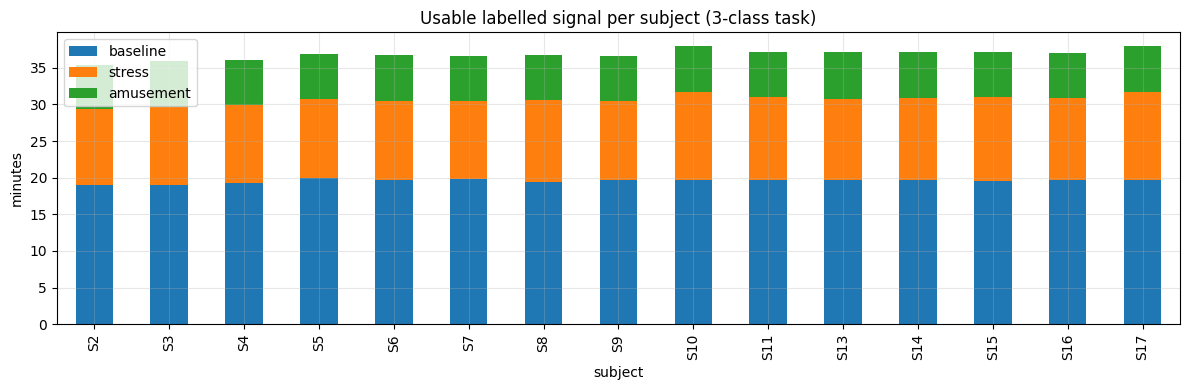

In [28]:
ax = label_df[["baseline", "stress", "amusement"]].plot(
    kind="bar", stacked=True, figsize=(12, 4)
)
ax.set_ylabel("minutes")
ax.set_title("Usable labelled signal per subject (3-class task)")
plt.tight_layout()
plt.show()

## 6b. Raw signal inspection for one subject, with the protocol shaded in

In [29]:
demo_channels, demo_labels, demo_subject = load_subject(PKL_FILES[0])

In [30]:
print(f"\nChannels for {demo_subject}:")
for name, (arr, fs) in demo_channels.items():
    print(f"  {name:<14} n={arr.size:>9}  fs={fs:>6.1f} Hz  "
          f"duration={arr.size / fs / 60:6.2f} min  "
          f"NaNs={int(np.isnan(arr).sum())}")


Channels for S2:
  chest_ECG      n=  4255300  fs= 700.0 Hz  duration=101.32 min  NaNs=0
  chest_EMG      n=  4255300  fs= 700.0 Hz  duration=101.32 min  NaNs=0
  chest_Resp     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCx     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCy     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCz     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCmag   n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_EDA      n=    42553  fs=   7.0 Hz  duration=101.32 min  NaNs=0
  chest_Temp     n=    42553  fs=   7.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCx     n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCy     n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCz     n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCmag   n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_BVP      n=   389056  fs=  64.0 Hz  du

In [31]:
# Sanity check: every channel must cover roughly the same wall-clock duration.
durations = {n: a.size / fs for n, (a, fs) in demo_channels.items()}
print(f"\nDuration spread across channels: "
      f"min={min(durations.values()):.1f}s, max={max(durations.values()):.1f}s")


Duration spread across channels: min=6079.0s, max=6079.0s


In [32]:
# Shade the label track behind the signals so the protocol is visible.
LABEL_COLORS = {1: "tab:green", 2: "tab:red", 3: "tab:orange", 4: "tab:blue"}

In [33]:
def shade_conditions(ax, labels, fs_label=700.0):
    """Shade contiguous blocks of labels 1-4 on a time axis in seconds."""
    changes = np.flatnonzero(np.diff(labels)) + 1
    bounds = np.concatenate(([0], changes, [labels.size]))
    for s, e in zip(bounds[:-1], bounds[1:]):
        code = int(labels[s])
        if code in LABEL_COLORS:
            ax.axvspan(s / fs_label, e / fs_label,
                       color=LABEL_COLORS[code], alpha=0.15, lw=0)

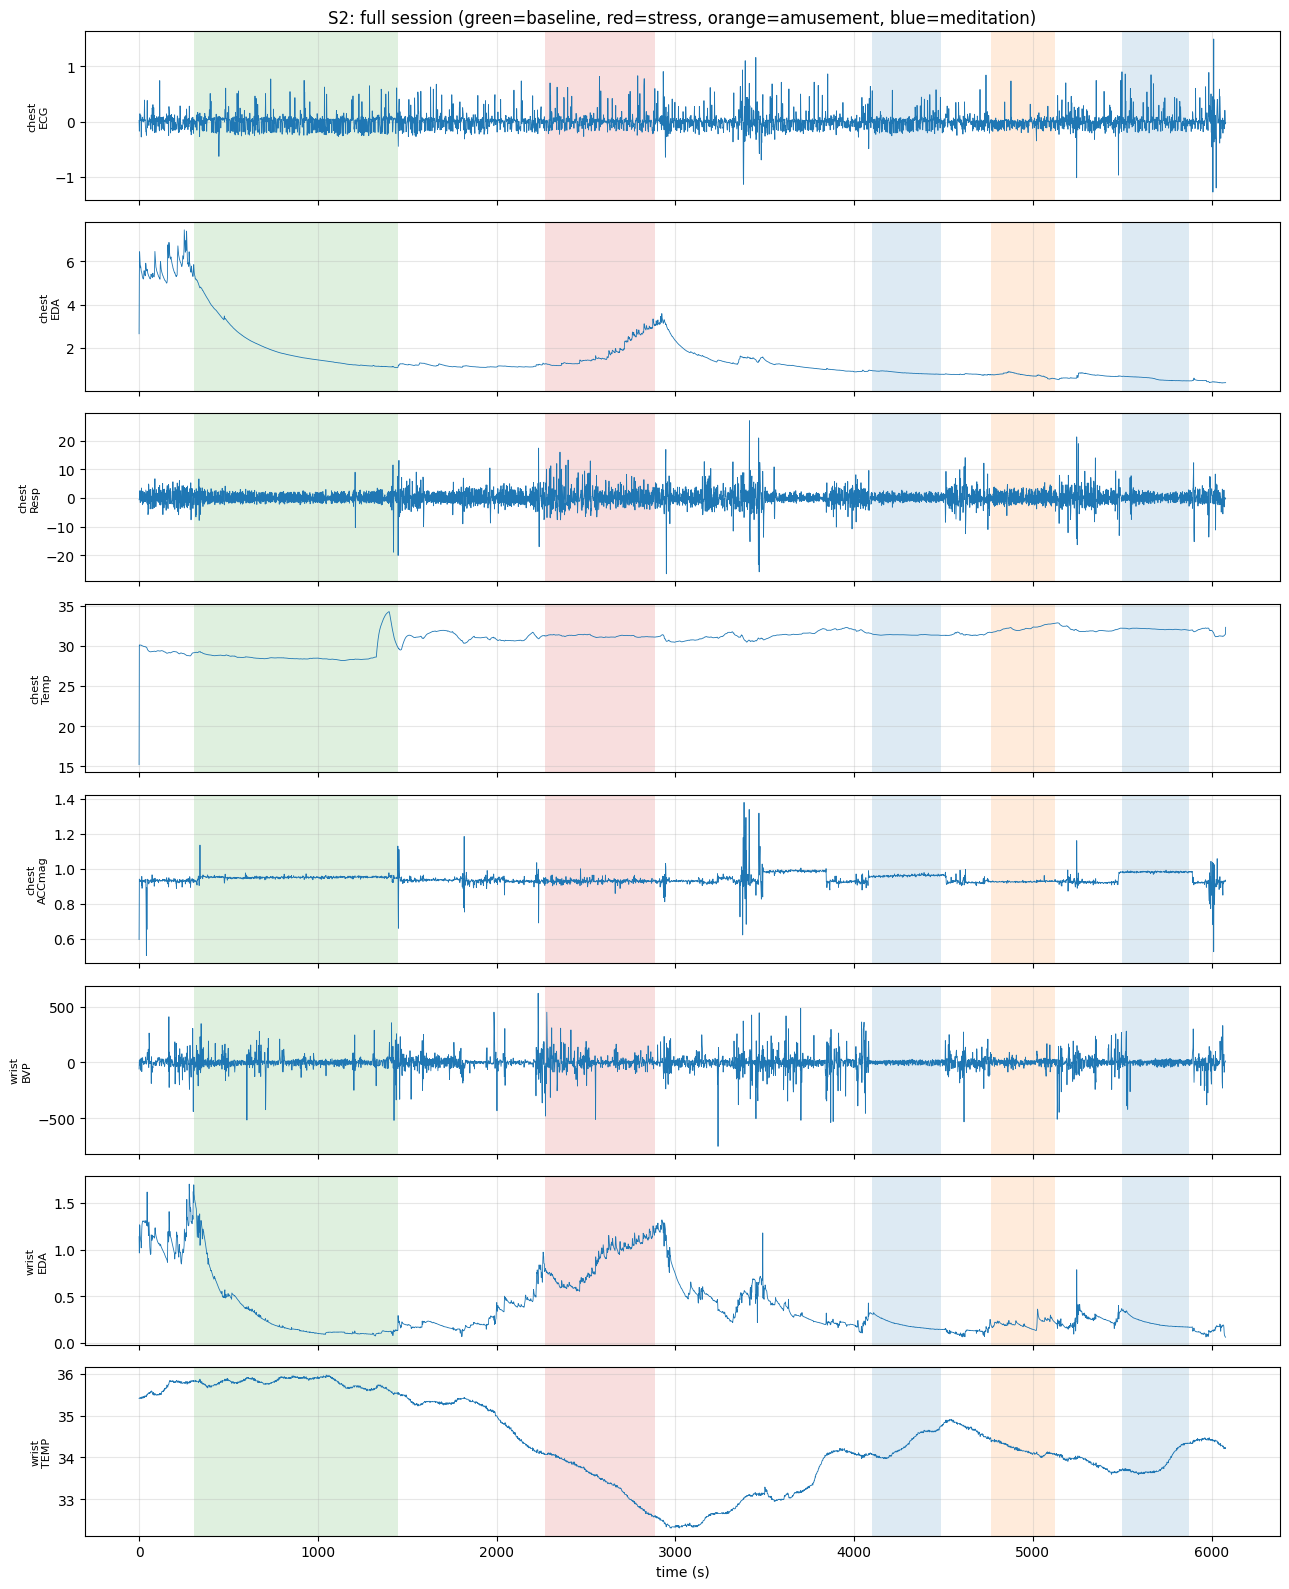

In [34]:
plot_channels = ["chest_ECG", "chest_EDA", "chest_Resp", "chest_Temp",
                 "chest_ACCmag", "wrist_BVP", "wrist_EDA", "wrist_TEMP"]
plot_channels = [c for c in plot_channels if c in demo_channels]

fig, axes = plt.subplots(len(plot_channels), 1, figsize=(13, 2.0 * len(plot_channels)),
                         sharex=True)
for ax, name in zip(np.atleast_1d(axes), plot_channels):
    arr, fs = demo_channels[name]
    # Plot at most ~4000 points per channel, otherwise the figure is unreadable
    # and slow. This is display-only decimation, the features use full rate.
    step = max(1, arr.size // 4000)
    t = np.arange(0, arr.size, step) / fs
    ax.plot(t, arr[::step], lw=0.6)
    ax.set_ylabel(name.replace("_", "\n"), fontsize=8)
    shade_conditions(ax, demo_labels)
np.atleast_1d(axes)[-1].set_xlabel("time (s)")
np.atleast_1d(axes)[0].set_title(
    f"{demo_subject}: full session (green=baseline, red=stress, "
    f"orange=amusement, blue=meditation)"
)
plt.tight_layout()
plt.show()

## 6c. Zoom on 20 s of ECG per condition. Visual confirmation that the ECG is clean enough for R-peak detection and that heart rate visibly rises in the stress condition.

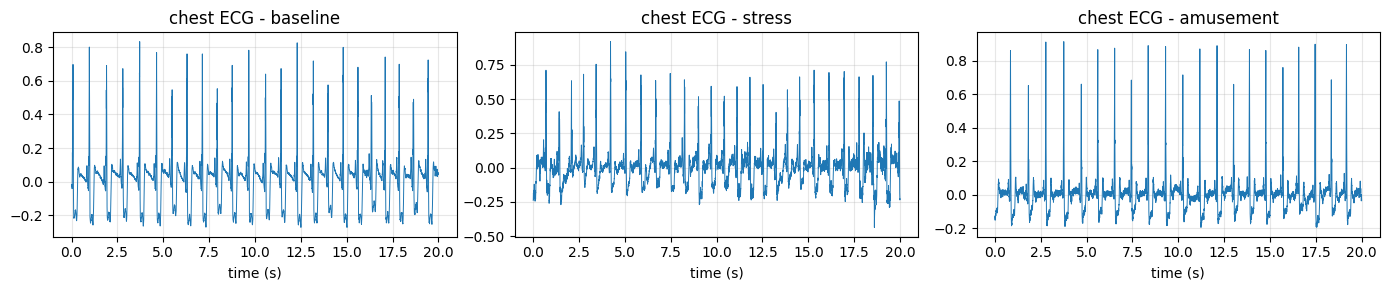

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (code, name) in zip(axes, [(1, "baseline"), (2, "stress"), (3, "amusement")]):
    idx = np.flatnonzero(demo_labels == code)
    ecg, fs = demo_channels["chest_ECG"]
    # Start 60 s into the block to skip the onset transient.
    start = int(idx[0] / 700.0 * fs) + int(60 * fs)
    seg = ecg[start:start + int(20 * fs)]
    ax.plot(np.arange(seg.size) / fs, seg, lw=0.7)
    ax.set_title(f"chest ECG - {name}")
    ax.set_xlabel("time (s)")
plt.tight_layout()
plt.show()

In [36]:
del demo_channels, demo_labels
gc.collect()

31331

# 7. Windowing and Feature Extraction Functions